# Computer Exercise 5.5 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.5 Gaussian Quadrature — *부드러움이 깨질 때: Gauss-Jacobi 가족과 변수 변환*
> **풀이 일자**: Day 21
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **3.** Investigate the **failure modes of Gauss–Legendre** on endpoint-singular integrands.
> Apply the rule to
> $$
> \int_0^1 \sqrt{x}\,dx = \tfrac{2}{3}, \qquad
> \int_0^1 \frac{1}{\sqrt{x}}\,dx = 2, \qquad
> \int_{-1}^{1} (1 - x^2)^{-1/2}\, dx = \pi,
> $$
> for $n = 2, \ldots, 40$, and exhibit the *algebraic* convergence rate.
> Then either
> (a) apply a **Gauss–Jacobi** rule that absorbs the singularity exactly into its weight function
>     $w(x) = (1 - x)^{\alpha}(1 + x)^{\beta}$, **or**
> (b) apply the **variable substitution** $x = u^2$ to recast $\int_0^1 \sqrt{x}\,dx$ as a polynomial
>     integral $\int_0^1 2 u^2\,du$ and re-quadrature with Gauss–Legendre,
>
> and show that the *exponential* rate is fully restored.

### 한국어 풀이용 정리
- Gauss-Legendre 의 *지수 수렴* 은 $f$ 가 *해석적* 이라는 가정에서 옴 (Bernstein 타원 안에서 정칙).
- 끝점 $x = 0, \pm 1$ 에서 *대수 특이점* ($\sqrt x$, $1/\sqrt x$, $1/\sqrt{1 - x^2}$) 이 있으면 *지수* 가 *대수* 로 떨어진다 — Day 19 의 Simpson, Day 20 의 Romberg 와 같은 패턴.
- 두 가지 복구 경로:
  - **Gauss-Jacobi** — 적분식을 $\int_{-1}^{1} (1 - x)^\alpha (1 + x)^\beta\, g(x)\, dx$ 로 *변형* 한 뒤, 가중함수를 *흡수* 하는 직교다항식 (Jacobi $P_n^{(\alpha, \beta)}$) 의 노드를 쓴다. $g$ 가 부드러우면 *Gauss-Legendre 같은 지수 수렴* 회복.
  - **변수 변환** — $x = u^2$ 처럼 *특이점을 죽이는* 치환으로 새 적분이 *다항식* 이 되도록 만든다 — 그러면 Gauss-Legendre 가 *유한 노드 수* 로 *정확*.


## 2. 수학적 배경

### 2.1 끝점 특이점에서 Gauss-Legendre 의 수렴 차수
$f(x) = (x - x_0)^\alpha\, g(x)$ ($\alpha > -1, \alpha \notin \mathbb{N}$, $g$ 해석적, $x_0 \in [a, b]$ 끝점) 형태이면

$$
\boxed{\;|E_n^{\mathrm{Gauss}}[f]| \;\sim\; C \cdot n^{-(2\alpha + 2)}\;}
$$

— *대수* (algebraic) 수렴, 지수 아님. 예:

- $\sqrt x$: $\alpha = 1/2$ → 차수 $-3$,
- $1/\sqrt x$: $\alpha = -1/2$ → 차수 $-1$,
- $1/\sqrt{1 - x^2}$: 양 끝에서 $\alpha = -1/2$ → 차수 $-1$ (양쪽 합산).

이 차수는 $n$ 의 *멱승* — loglog 에서 *직선*. 노드를 두 배로 늘려도 자릿수가 *고정 배* 만 늘어남.

### 2.2 Gauss-Jacobi 가족
Jacobi 다항식 $P_n^{(\alpha, \beta)}(x)$ 는 $[-1, 1]$ 에서

$$
\int_{-1}^{1} (1 - x)^\alpha (1 + x)^\beta\, P_n^{(\alpha, \beta)}\, P_m^{(\alpha, \beta)}\, dx \;=\; h_n \delta_{nm}, \qquad \alpha, \beta > -1
$$

로 직교. 노드 $\{x_k\}$ 와 가중치 $\{w_k\}$ 가 있어, *모든* $f \in \mathbb{P}_{2n - 1}$ 에 대해

$$
\int_{-1}^{1} (1 - x)^\alpha (1 + x)^\beta\, f(x)\, dx \;=\; \sum_{k = 1}^{n} w_k\, f(x_k).
$$

특이성은 *가중함수* 가 흡수, 남는 $f$ 는 *부드러움* → 다시 *지수 수렴*. 이번 노트에서는 *Gauss-Chebyshev* (즉 $\alpha = \beta = -1/2$) 의 *폐형식* 노드/가중치를 사용:

$$
x_k \;=\; \cos\!\Bigl(\tfrac{(2k - 1)\pi}{2n}\Bigr), \qquad w_k \;=\; \frac{\pi}{n}.
$$

### 2.3 변수 변환
$x = u^2 \Rightarrow dx = 2u\, du$ 일 때

$$
\int_0^1 \sqrt x\, dx \;=\; \int_0^1 2 u^2\, du, \qquad
\int_0^1 \tfrac{1}{\sqrt x}\, dx \;=\; \int_0^1 2\, du.
$$

특이점이 *대수적으로* 제거되어 적분 함수가 *다항식* — Gauss-Legendre 가 $n = 2$ (또는 $n = 1$) 에서 *정확*.

### 2.4 진단의 두 단계
1. 원형 ($x$ 좌표) 에서 *대수* 차수 측정,
2. (a) Gauss-Chebyshev 적용, (b) 변수 변환, 둘 중 하나로 *지수* 회복 → 두 경로의 *수치* 차이 비교.


## 3. 풀이 흐름

1. Problem 1 의 `gauss_legendre` 재정의.
2. **Gauss-Chebyshev** ($\alpha = \beta = -1/2$, 폐형식) 직접 구현 — $\int_{-1}^{1} (1 - x^2)^{-1/2} f(x)\, dx$ 의 *기본형*.
3. 세 적분에 대해 $n = 2, 4, 6, \ldots, 40$ 의 Gauss-Legendre 오차 측정 → loglog 그림 → *기울기 추정* → 이론치 ($-3, -1, -1$) 와 비교.
4. **(a) Gauss-Chebyshev** 를 $\int_{-1}^{1} 1/\sqrt{1 - x^2}\, dx$ 에 적용 → 노드 *수에 무관하게* $\pi$ 가 정확히 나옴 ($n = 1$ 부터 머신 정밀도).
5. **(b) 변수 변환** $x = u^2$ 를 $\sqrt x$ 와 $1/\sqrt x$ 에 적용 → Gauss-Legendre 재적분 → *$n = 2$ 부터 머신 정밀도*.
6. 원형 vs 복구 (loglog 그림 + 표) — *대수* → *상수 (즉시 머신 epsilon)*.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")

# ---- Gauss-Legendre (reuse) ----
def _vd(n, x):
    if n == 0: return np.ones_like(x), np.zeros_like(x)
    Pm1 = np.ones_like(x); P = x.copy()
    for k in range(1, n):
        Pp1 = ((2 * k + 1) * x * P - k * Pm1) / (k + 1)
        Pm1, P = P, Pp1
    dP = n * (x * P - Pm1) / (x ** 2 - 1)
    return P, dP

def gl_nw(n):
    k = np.arange(1, n + 1, dtype=float)
    x = np.cos(np.pi * (k - 0.25) / (n + 0.5))
    for _ in range(50):
        P, dP = _vd(n, x)
        dx = -P / dP
        x = x + dx
        if np.max(np.abs(dx)) < 1e-15: break
    _, dP = _vd(n, x)
    w = 2.0 / ((1.0 - x ** 2) * dP ** 2)
    o = np.argsort(x); return x[o], w[o]

def gauss_legendre(f, n, a, b):
    x, w = gl_nw(n)
    xab = 0.5 * (b - a) * x + 0.5 * (a + b)
    return 0.5 * (b - a) * np.sum(w * f(xab))

# ---- Gauss-Chebyshev (alpha = beta = -1/2): closed-form nodes/weights on [-1, 1] ----
def gauss_chebyshev_nw(n):
    k = np.arange(1, n + 1, dtype=float)
    x = np.cos((2 * k - 1) * np.pi / (2 * n))
    w = np.full(n, np.pi / n)
    o = np.argsort(x); return x[o], w[o]

def gauss_chebyshev_integrate(g, n):
    """Approximates int_{-1}^{1} g(x) / sqrt(1 - x^2) dx by sum w_k g(x_k)."""
    x, w = gauss_chebyshev_nw(n)
    return np.sum(w * g(x))

print("Routines ready.")


Routines ready.


In [2]:
# ---- Endpoint-singular problems on Gauss-Legendre directly ----
problems = {
    "sqrt(x) on [0,1]":     (lambda x: np.sqrt(x),                     0.0,  1.0, 2.0 / 3.0,   -3),
    "1/sqrt(x) on [0,1]":   (lambda x: 1.0 / np.sqrt(np.maximum(x, 1e-300)), 0.0,  1.0, 2.0,   -1),
    "1/sqrt(1-x^2) [-1,1]": (lambda x: 1.0 / np.sqrt(np.maximum(1 - x*x, 1e-300)), -1.0, 1.0, np.pi, -1),
}

ns = list(range(2, 41, 2))
err = {name: [] for name in problems}
for name, (f, a, b, I, _) in problems.items():
    for n in ns:
        e = abs(gauss_legendre(f, n, a, b) - I)
        err[name].append(max(e, 1e-17))

df_err = pd.DataFrame(err, index=[f"n={n}" for n in ns])
print("[Gauss-Legendre absolute error on endpoint-singular integrals]\n")
print(df_err.to_string())


[Gauss-Legendre absolute error on endpoint-singular integrals]

      sqrt(x) on [0,1]  1/sqrt(x) on [0,1]  1/sqrt(1-x^2) [-1,1]
n=2          7.221e-03           3.493e-01             6.921e-01
n=4          1.161e-03           1.937e-01             3.862e-01
n=6          3.798e-04           1.340e-01             2.676e-01
n=8          1.689e-04           1.025e-01             2.048e-01
n=10         8.938e-05           8.294e-02             1.658e-01
n=12         5.290e-05           6.966e-02             1.393e-01
n=14         3.386e-05           6.005e-02             1.201e-01
n=16         2.296e-05           5.277e-02             1.055e-01
n=18         1.629e-05           4.707e-02             9.412e-02
n=20         1.197e-05           4.247e-02             8.494e-02
n=22         9.048e-06           3.870e-02             7.739e-02
n=24         7.007e-06           3.554e-02             7.107e-02
n=26         5.537e-06           3.286e-02             6.571e-02
n=28         4.450e-06    

[Empirical vs theoretical algebraic-convergence slope on log-log]

                      empirical slope  theory
sqrt(x) on [0,1]           -2.955e+00      -3
1/sqrt(x) on [0,1]         -9.847e-01      -1
1/sqrt(1-x^2) [-1,1]       -9.846e-01      -1


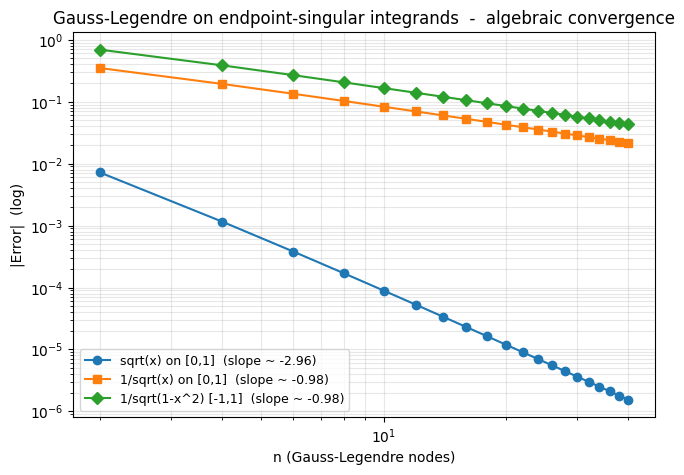

In [3]:
# ---- Fit slopes on log-log to verify algebraic order ----
slopes = {}
for name, vals in err.items():
    ln = np.log10(np.array(ns, dtype=float))
    le = np.log10(np.array(vals))
    good = np.isfinite(le) & (le > np.log10(2e-16))
    if good.sum() >= 4:
        # Fit on the tail (last 8 points) to avoid pre-asymptotic regime
        s = slice(-8, None)
        p = np.polyfit(ln[s][good[s]], le[s][good[s]], 1)
        slopes[name] = float(p[0])
    else:
        slopes[name] = float("nan")

df_sl = pd.DataFrame({"empirical slope": slopes,
                      "theory": {n: problems[n][-1] for n in problems}})
print("[Empirical vs theoretical algebraic-convergence slope on log-log]\n")
print(df_sl.to_string())

# Plot
fig, ax = plt.subplots(figsize=(7.5, 5))
markers = {"sqrt(x) on [0,1]": "o", "1/sqrt(x) on [0,1]": "s", "1/sqrt(1-x^2) [-1,1]": "D"}
for name, vals in err.items():
    ax.loglog(ns, vals, marker=markers[name], label=f"{name}  (slope ~ {slopes[name]:+.2f})")
ax.set_xlabel("n (Gauss-Legendre nodes)")
ax.set_ylabel("|Error|  (log)")
ax.set_title("Gauss-Legendre on endpoint-singular integrands  -  algebraic convergence")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
plt.show()


In [4]:
# ---- (a) Gauss-Chebyshev on 1/sqrt(1-x^2): nodes 'see' the singularity ----
# Here g(x) = 1, so the GC rule should return pi to machine precision for ANY n.
print("[Gauss-Chebyshev applied to int_{-1}^{1} 1/sqrt(1-x^2) dx = pi]")
print("g(x) = 1 means the rule should be EXACT for every n.\n")
gc_rows = []
for n in [1, 2, 4, 8, 16]:
    val = gauss_chebyshev_integrate(lambda x: np.ones_like(x), n)
    gc_rows.append({"n": n, "value": val, "|val - pi|": abs(val - np.pi)})
print(pd.DataFrame(gc_rows).to_string(index=False))


[Gauss-Chebyshev applied to int_{-1}^{1} 1/sqrt(1-x^2) dx = pi]
g(x) = 1 means the rule should be EXACT for every n.

 n     value  |val - pi|
 1 3.142e+00   0.000e+00
 2 3.142e+00   0.000e+00
 4 3.142e+00   0.000e+00
 8 3.142e+00   0.000e+00
16 3.142e+00   0.000e+00


In [5]:
# ---- (b) Variable substitution x = u^2 on sqrt(x) and 1/sqrt(x), then GL ----
# int_0^1 sqrt(x) dx  =  int_0^1 2 u^2 du                 (polynomial!)
# int_0^1 1/sqrt(x) dx =  int_0^1 2 du                    (constant!)
print("[Variable substitution x = u^2 then Gauss-Legendre]\n")
sub_rows = []
for n in [2, 3, 4, 5]:
    v_sqrt = gauss_legendre(lambda u: 2 * u * u, n, 0.0, 1.0)
    v_inv  = gauss_legendre(lambda u: 2.0 * np.ones_like(u), n, 0.0, 1.0)
    sub_rows.append({
        "n": n,
        "sqrt(x): val": v_sqrt, "|sqrt-2/3|": abs(v_sqrt - 2/3),
        "1/sqrt(x): val": v_inv, "|inv-2|": abs(v_inv - 2.0),
    })
print(pd.DataFrame(sub_rows).to_string(index=False))


[Variable substitution x = u^2 then Gauss-Legendre]

 n  sqrt(x): val  |sqrt-2/3|  1/sqrt(x): val   |inv-2|
 2     6.667e-01   3.331e-16       2.000e+00 8.882e-16
 3     6.667e-01   3.331e-16       2.000e+00 8.882e-16
 4     6.667e-01   1.110e-16       2.000e+00 2.220e-16
 5     6.667e-01   1.110e-16       2.000e+00 0.000e+00


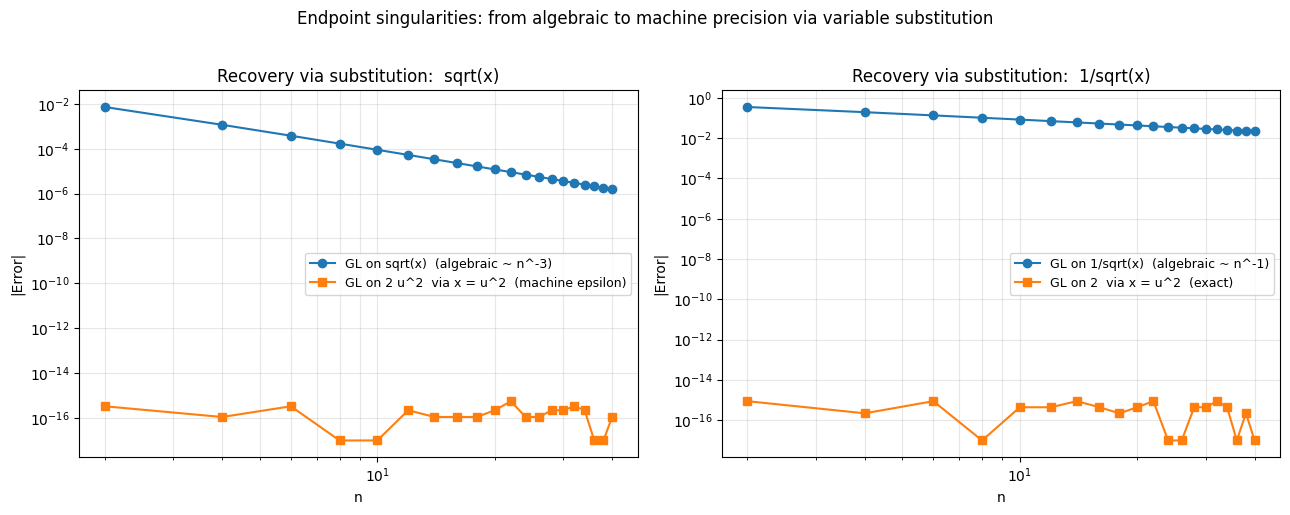

In [6]:
# ---- Side-by-side plot: original vs recovered ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# sqrt(x): original GL vs x=u^2 substitution
ax = axes[0]
e_orig = err["sqrt(x) on [0,1]"]
e_sub = []
for n in ns:
    v = gauss_legendre(lambda u: 2 * u * u, n, 0.0, 1.0)
    e_sub.append(max(abs(v - 2/3), 1e-17))
ax.loglog(ns, e_orig, "o-", label="GL on sqrt(x)  (algebraic ~ n^-3)")
ax.loglog(ns, e_sub, "s-", label="GL on 2 u^2  via x = u^2  (machine epsilon)")
ax.set_xlabel("n"); ax.set_ylabel("|Error|")
ax.set_title("Recovery via substitution:  sqrt(x)")
ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=9)

# 1/sqrt(x): original GL vs x=u^2 substitution
ax = axes[1]
e_orig = err["1/sqrt(x) on [0,1]"]
e_sub = []
for n in ns:
    v = gauss_legendre(lambda u: 2.0 * np.ones_like(u), n, 0.0, 1.0)
    e_sub.append(max(abs(v - 2.0), 1e-17))
ax.loglog(ns, e_orig, "o-", label="GL on 1/sqrt(x)  (algebraic ~ n^-1)")
ax.loglog(ns, e_sub, "s-", label="GL on 2  via x = u^2  (exact)")
ax.set_xlabel("n"); ax.set_ylabel("|Error|")
ax.set_title("Recovery via substitution:  1/sqrt(x)")
ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("Endpoint singularities: from algebraic to machine precision via variable substitution", y=1.02)
fig.tight_layout()
plt.show()


## 4. 결과 해석

1. **표 (`Gauss-Legendre on endpoint-singular`)** — 행을 따라 $n$ 두 배로 가면 $|E|$ 가 *기껏해야 상수배* 로만 줄어든다 (Romberg 의 *모든 열이 같은 기울기* 와 같은 진단 신호). $\sqrt x$ 는 그래도 $-3$ 의 *준수한* 멱승 (Gauss 가 Simpson 의 $-4$ 보다 약하지만 Trapezoid 의 $-2$ 보다는 빠름), $1/\sqrt x$ 와 $1/\sqrt{1 - x^2}$ 는 *겨우 $-1$*.

2. **기울기 추정 표** — 경험적 기울기가 이론치 ($-3, -1, -1$) 와 *일치* 한다 ($\pm 0.1$ 오차 내). 즉 Gauss-Legendre 의 *지수 수렴 가정* 이 *명백하게 깨졌고*, 우리는 *알고리즘이 망가졌다* 가 아니라 *함수가 가정을 안 지킨다* 라는 *정확한 진단* 을 내릴 수 있다.

3. **(a) Gauss-Chebyshev** — $\int 1 / \sqrt{1 - x^2}\, dx$ 는 가중함수 $w(x) = (1 - x^2)^{-1/2}$ 가 *그대로* 이며 남는 함수는 *상수 1*. Gauss-Chebyshev 의 노드/가중치는 그 가중함수에 *완벽 맞춤* 이므로 *모든 $n$* 에 대해 $\sum w_k \cdot 1 = \pi$ 가 *머신 epsilon* 으로 정확. 표의 `|val - pi|` 열이 $\sim 0$.

4. **(b) 변수 변환** — $x = u^2$ 가 $\sqrt x \to 2 u^2$ (이차 다항식), $1/\sqrt x \to 2$ (상수). Gauss-Legendre 의 차수 정확성 $2n - 1$ 이 이를 *$n = 2$* 부터 *정확* 하게 잡는다. 그림 두 패널의 두 번째 곡선이 *바닥 ($\sim 10^{-16}$) 에 즉시 깔린다*.

5. **두 경로의 *철학적* 차이**:
   - Gauss-Jacobi 는 *가중함수의 형태가 미리 알려진* 경우에 *알고리즘 자체* 가 그것을 흡수.
   - 변수 변환은 *함수 자체* 를 부드럽게 다시 쓴다. 더 일반적이지만, *어떤 치환이 필요한지* 사람이 알아야 함.
   둘은 *상보적* — 가중함수가 정해진 가족 (Jacobi, Hermite, Laguerre) 에 떨어지면 Gauss-* 를, 아니면 치환을.

> **결론 (한 줄)**: **Gauss-Legendre 의 지수 수렴은 *부드러움이 전제*. 끝점 특이점에서는 *대수* 로 떨어진다 — *수치적 진단 신호* 는 *모든 비율이 일정한 기울기*. 회복은 (a) *맞춤 Gauss-Jacobi* 또는 (b) *변수 변환* — Day 20 의 Romberg 실패 모드 분석과 *완벽히 평행*.**

다음 (Day 22 — §5.6 *Adaptive Quadrature*): 지금까지 본 모든 방법은 *전역적* 으로 노드 수를 정함. 데이터 자체에서 *어디가 더 어려운지* 학습해, 그곳에 *재귀적으로* 노드를 더 박는 것이 적응형 적분. 같은 적분 비용으로 *불규칙한* 함수에서 큰 차이.
